In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart_disease_dataset.csv to heart_disease_dataset.csv


In [ ]:
import pandas as pd

df = pd.read_csv('heart_disease_dataset.csv')

df.head()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

In [ ]:
print("Shape:", df.shape)

Shape: (400, 14)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    int64  
 1   sex                      400 non-null    int64  
 2   chest_pain_type          400 non-null    int64  
 3   resting_blood_pressure   400 non-null    int64  
 4   cholesterol              400 non-null    int64  
 5   fasting_blood_sugar      400 non-null    int64  
 6   resting_ecg              400 non-null    int64  
 7   max_heart_rate           400 non-null    int64  
 8   exercise_induced_angina  400 non-null    int64  
 9   st_depression            400 non-null    float64
 10  st_slope                 400 non-null    int64  
 11  num_major_vessels        400 non-null    int64  
 12  thalassemia              400 non-null    int64  
 13  heart_disease            400 non-null    int64  
dtypes: float64(1), int64(13)
m

In [ ]:
df.describe()

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,53.667500,0.662500,1.712500,123.630000,216.627500,0.140000,0.530000,146.717500,0.29250,0.753250,1.177500,0.677500,1.925000,0.555000
std,8.508403,0.473449,1.035628,16.567114,41.379941,0.347422,0.533678,21.104293,0.45548,0.772841,0.645784,0.889084,0.689611,0.497588
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,91.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,1.000000,112.000000,188.000000,0.000000,0.000000,132.000000,0.00000,0.200000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,2.000000,124.000000,216.000000,0.000000,1.000000,146.000000,0.00000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,59.000000,1.000000,3.000000,135.000000,246.000000,0.000000,1.000000,161.000000,1.00000,0.900000,2.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,174.000000,336.000000,1.000000,2.000000,202.000000,1.00000,4.900000,2.000000,3.000000,3.000000,1.000000


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_blood_pressure,0
cholesterol,0
fasting_blood_sugar,0
resting_ecg,0
max_heart_rate,0
exercise_induced_angina,0
st_depression,0


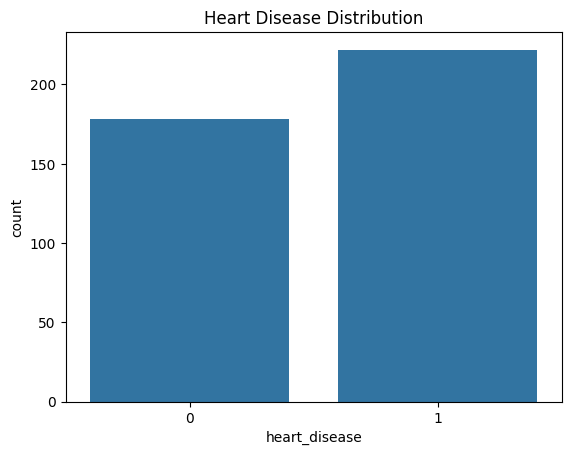

In [ ]:
sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

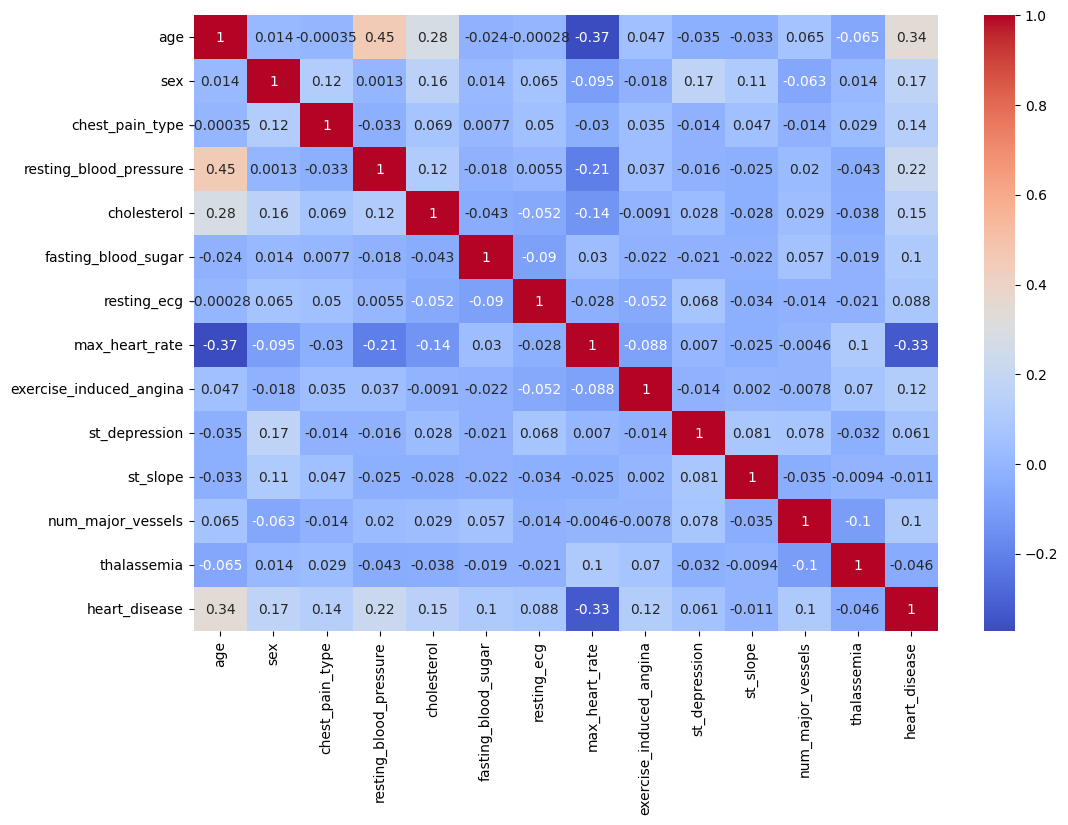

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

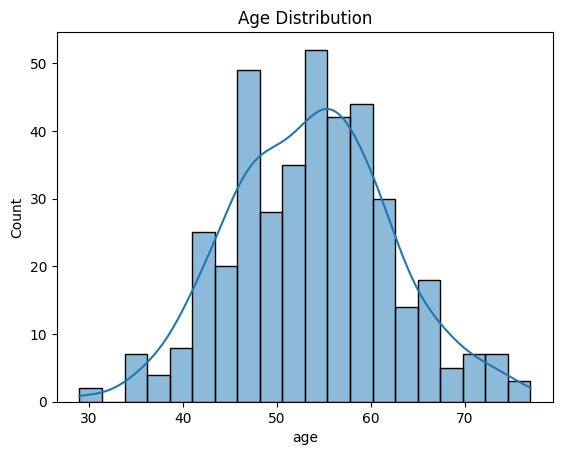

In [ ]:
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

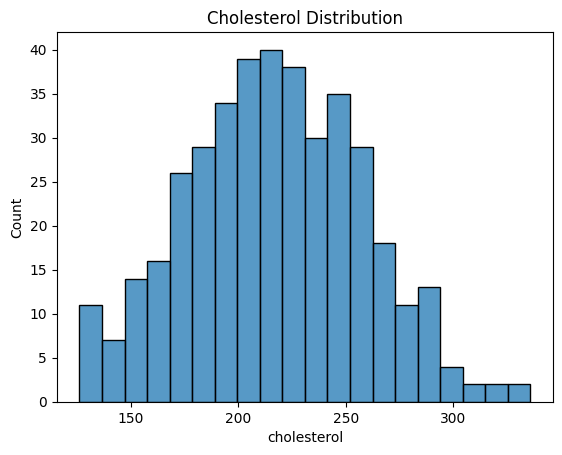

In [ ]:
sns.histplot(df['cholesterol'], bins=20)
plt.title("Cholesterol Distribution")
plt.show()

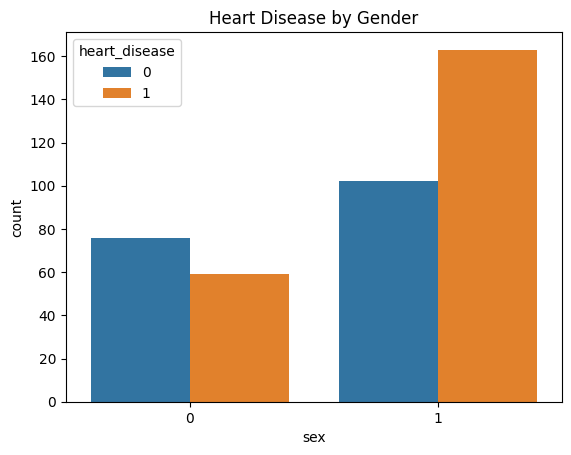

In [ ]:
sns.countplot(x='sex', hue='heart_disease', data=df)
plt.title("Heart Disease by Gender")
plt.show()

In [ ]:
X = df.drop('heart_disease', axis=1)

y = df['heart_disease']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(320, 13)
(80, 13)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

y_prob_dt = dt.predict_proba(X_test)[:,1]

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
svm = SVC(
    probability=True,
    kernel='rbf'
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)

y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]

In [ ]:
def evaluate_model(y_test, y_pred, y_prob):

    cm = confusion_matrix(y_test, y_pred)

    TN, FP, FN, TP = cm.ravel()

    specificity = TN/(TN+FP)

    print("Accuracy :", accuracy_score(y_test,y_pred))
    print("Precision :", precision_score(y_test,y_pred))
    print("Recall :", recall_score(y_test,y_pred))
    print("F1 Score :", f1_score(y_test,y_pred))
    print("ROC AUC :", roc_auc_score(y_test,y_prob))
    print("Specificity :", specificity)

    print("\nClassification Report")
    print(classification_report(y_test,y_pred))

    sns.heatmap(cm,annot=True,fmt='d')
    plt.show()

Accuracy : 0.675
Precision : 0.6956521739130435
Recall : 0.7272727272727273
F1 Score : 0.7111111111111111
ROC AUC : 0.7342171717171717
Specificity : 0.6111111111111112

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.61      0.63        36
           1       0.70      0.73      0.71        44

    accuracy                           0.68        80
   macro avg       0.67      0.67      0.67        80
weighted avg       0.67      0.68      0.67        80



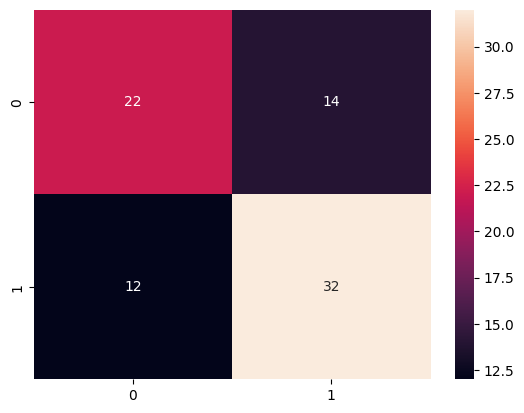

In [ ]:
evaluate_model(y_test,y_pred_lr,y_prob_lr)

Accuracy : 0.575
Precision : 0.6
Recall : 0.6818181818181818
F1 Score : 0.6382978723404256
ROC AUC : 0.5631313131313131
Specificity : 0.4444444444444444

Classification Report
              precision    recall  f1-score   support

           0       0.53      0.44      0.48        36
           1       0.60      0.68      0.64        44

    accuracy                           0.57        80
   macro avg       0.57      0.56      0.56        80
weighted avg       0.57      0.57      0.57        80



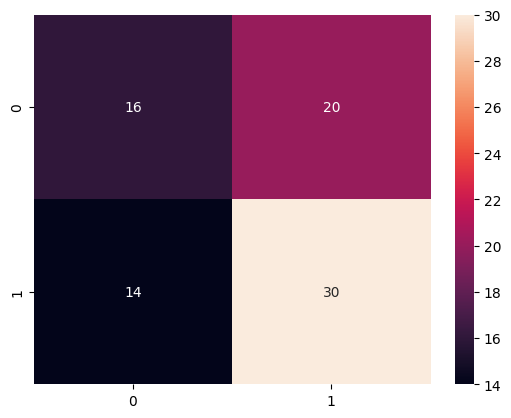

In [ ]:
evaluate_model(y_test,y_pred_dt,y_prob_dt)

Accuracy : 0.6625
Precision : 0.673469387755102
Recall : 0.75
F1 Score : 0.7096774193548387
ROC AUC : 0.76010101010101
Specificity : 0.5555555555555556

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.56      0.60        36
           1       0.67      0.75      0.71        44

    accuracy                           0.66        80
   macro avg       0.66      0.65      0.65        80
weighted avg       0.66      0.66      0.66        80



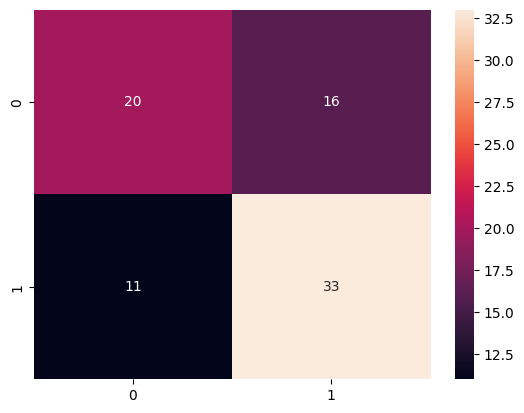

In [ ]:
evaluate_model(y_test,y_pred_rf,y_prob_rf)

Accuracy : 0.65
Precision : 0.6739130434782609
Recall : 0.7045454545454546
F1 Score : 0.6888888888888889
ROC AUC : 0.7351641414141414
Specificity : 0.5833333333333334

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.58      0.60        36
           1       0.67      0.70      0.69        44

    accuracy                           0.65        80
   macro avg       0.65      0.64      0.64        80
weighted avg       0.65      0.65      0.65        80



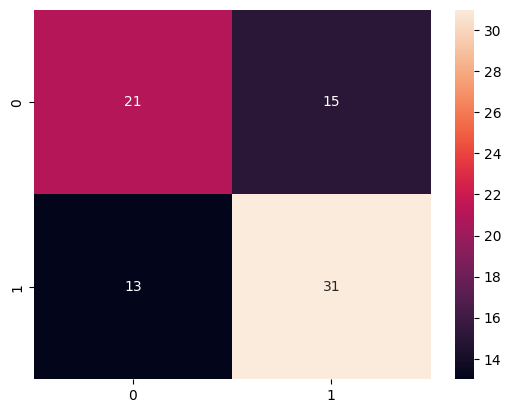

In [ ]:
evaluate_model(y_test,y_pred_svm,y_prob_svm)

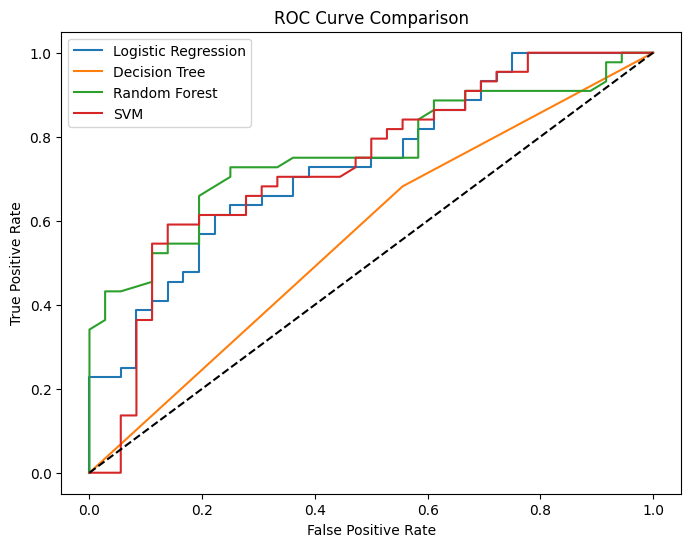

In [ ]:
plt.figure(figsize=(8,6))

for probs,name in [
    (y_prob_lr,'Logistic Regression'),
    (y_prob_dt,'Decision Tree'),
    (y_prob_rf,'Random Forest'),
    (y_prob_svm,'SVM')
]:

    fpr,tpr,_=roc_curve(y_test,probs)

    plt.plot(fpr,tpr,label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

In [ ]:
results = pd.DataFrame({
    'Model':['Logistic Regression',
             'Decision Tree',
             'Random Forest',
             'SVM'],

    'Accuracy':[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_dt),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_svm)
    ],

    'Precision':[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_dt),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_svm)
    ],

    'Recall':[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_dt),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_svm)
    ],

    'F1 Score':[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_dt),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_svm)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6750,0.695652,0.727273,0.711111
1,Decision Tree,0.5750,0.600000,0.681818,0.638298
2,Random Forest,0.6625,0.673469,0.750000,0.709677
3,SVM,0.6500,0.673913,0.704545,0.688889


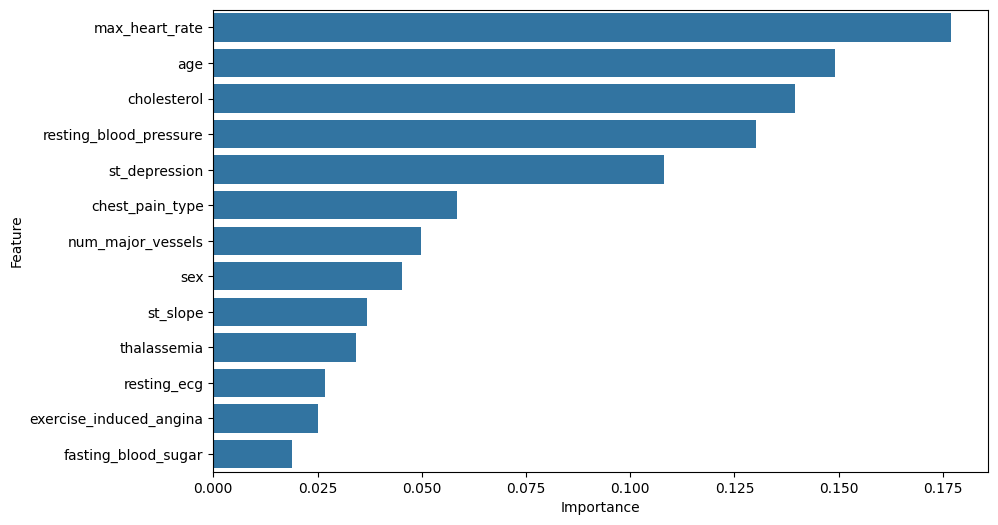

In [ ]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)
plt.show()

In [ ]:
import joblib

joblib.dump(rf,'heart_disease_model.pkl')

joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

In [ ]:
from fastapi import FastAPI
import joblib
import numpy as np

app = FastAPI()

model = joblib.load("heart_disease_model.pkl")

@app.get("/")
def home():
    return {"message":"Heart Disease Prediction API"}

@app.post("/predict")
def predict(features:list):

    data = np.array(features).reshape(1,-1)

    prediction = model.predict(data)

    return {
        "prediction":int(prediction[0])
    }

In [ ]:
%%writefile Dockerfile
FROM python:3.11

WORKDIR /app

COPY . .

RUN pip install fastapi uvicorn scikit-learn pandas numpy joblib

CMD ["uvicorn","app:app","--host","0.0.0.0","--port","8000"]

Writing Dockerfile


In [ ]:
rf

RandomForestClassifier(random_state=42)

In [ ]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print(prediction)

[1]


In [ ]:
print("Actual:", y_test.iloc[0])

Actual: 0


In [ ]:
sample = X_test.iloc[[0]]

prediction = rf.predict(sample)

print("Actual:", y_test.iloc[0])
print("Predicted:", prediction[0])

Actual: 0
Predicted: 1


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy)

Accuracy: 0.6625


In [ ]:
print(X.columns)

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_induced_angina', 'st_depression', 'st_slope',
       'num_major_vessels', 'thalassemia'],
      dtype='object')


In [ ]:
new_patient = [[
    55, 1, 2, 140,
    250, 0, 1,
    150, 0,
    1.5, 2, 0,
    2
]]
prediction = rf.predict(new_patient)

print(prediction)

if prediction[0] == 1:
    print("Heart Disease Detected")
else:
    print("No Heart Disease")

[1]
Heart Disease Detected


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf
})

comparison.head(10)

,Actual,Predicted
0,0,1
1,1,0
2,1,0
3,1,1
4,1,1
5,1,1
6,0,0
7,0,1
8,1,1
9,1,1


In [ ]:
import joblib

joblib.dump(rf, "heart_disease_model.pkl")

['heart_disease_model.pkl']

In [ ]:
!ls

Dockerfile		   heart_disease_model.pkl  scaler.pkl
heart_disease_dataset.csv  sample_data


In [ ]:
%%writefile app.py

from fastapi import FastAPI
from typing import List
import joblib
import numpy as np
import os

app = FastAPI()

# Get the directory where app.py is located
APP_DIR = os.path.dirname(os.path.abspath(__file__))

# Construct absolute paths to the model and scaler files
model_path = os.path.join(APP_DIR, "heart_disease_model.pkl")
scaler_path = os.path.join(APP_DIR, "scaler.pkl")

model = joblib.load(model_path)
scaler = joblib.load(scaler_path)

@app.get("/")
def home():
    return {
        "message": "Heart Disease Prediction API"
    }

@app.post("/predict")
def predict(features: List[float]):
    # Scale the input features
    scaled_features = scaler.transform(np.array(features).reshape(1, -1))

    prediction = model.predict(scaled_features)

    return {
        "prediction": int(prediction[0])
    }

Writing app.py


In [ ]:
!uvicorn app:app --host 0.0.0.0 --port 8000 > log.txt 2>&1 &

In [ ]:
!cat log.txt

INFO:     Started server process [1855]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [ ]:
!pip install fastapi uvicorn pyngrok

In [ ]:
!uvicorn app:app --host 0.0.0.0 --port 8000 &

INFO:     Started server process [1934]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [ ]:
!cat log.txt

INFO:     Started server process [1855]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


In [ ]:
!pip install pyngrok

In [ ]:
from pyngrok import ngrok

# Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3FcKp5Q3cN0dk1c9ZA7hr2RcdGp_3vFTNnDSNJsR2uGV9xKsR")
public_url = ngrok.connect(8000)

print(public_url)

NgrokTunnel: "https://handstand-turmoil-recollect.ngrok-free.dev" -> "http://localhost:8000"


In [ ]:
!pkill -f uvicorn

In [ ]:
!uvicorn app:app --host 0.0.0.0 --port 8000 > log.txt 2>&1 &

In [ ]:
from pyngrok import ngrok

# Replace 'YOUR_AUTHTOKEN' with your actual ngrok authtoken
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token("3FcKp5Q3cN0dk1c9ZA7hr2RcdGp_3vFTNnDSNJsR2uGV9xKsR")

# Kill any running ngrok tunnels
ngrok.kill()

public_url = ngrok.connect(8000)

print(public_url)

NgrokTunnel: "https://handstand-turmoil-recollect.ngrok-free.dev" -> "http://localhost:8000"
